# Introduction to Neural Network Classification

In my previous article, I have shown you how easily we can make a regression model using TensorFlow.

In this article, I'm going to discuss classification models using TensorFlow.

- [LinkedIn](https://www.linkedin.com/in/pro-programmer/),
- [YouTube](http://www.youtube.com/@itvaya),
- [Gmail](talukderrishat2@gmail.com),
- [discord](https://discord.gg/ZB495XggcF),

**You can find all my articles and code on**

- [Deep Learning With Tensorflow](https://github.com/RishatTalukder/Deep_Learning_With_Tensorflow),

**If you are new to Machine learning, I also have a github for begennier machine learning.**

- [Machine Learning Zero to Hero](https://github.com/RishatTalukder/Machine-Learning-Zero-to-Hero)

**Pre-requisites**

- Python.
- Numpy.
- Pandas.
- Matplotlib/Seaborn.
- Basics of data analysis and preprocessing.
- Basics ML terminologies.
- Basics Tensorflow and keras terminologies.
- Basics of Neural Network.

**Installations**

So, as we are making a `neural network using TensorFlow`, we will need to install it. To do so, we will use the following command:

```bash
    pip install tensorflow
```

or If you have conda installed,
    
```bash
    conda install tensorflow
```

Now, let's import the necessary libraries and check the version of TensorFlow we are using.

# Introduction

First let's answer the question "What is Classification?"

`Classification` Is  the process of grouping data points into `categories` or `classes` based on some criteria.

Simply put, when A model predicts a `category` instead of a `value`, it is called a `classification model`.

For example, a model that predicts whether a customer will buy a product or not is a classification model.

Or, let's say you have a dataset of images of cats and dogs. The model will  onyl predict whether the image is a cat or a dog.

Here's the model is not predicting a value but a `group`.


There can be two types of classification models:

- Binary classification.
- Multi-class classification.

**Binary classification**

In binary classification, the model predicts `two` categories. For example,

Let's say we have a dataset like this:

|   |   |  Target |
| --- | --- | --- |
| 1 | 1 | 1 |
| 2 | 1 | 0 |
| 3 | 0 | 1 |
| 4 | 0 | 0 |
| 5 | 1 | 0 |
| 6 | 0 | 1 |
| 7 | 1 | 1 |
| 8 | 0 | 0 |
| 9 | 1 | 1 |

As you can see the target feature only have two categories `0` and `1`. And the model will predict `0` or `1` based on the features.

**Multi-class classification**

In multi-class classification, the model predicts; Drum Roll please 🥁; You guessed it, `more than two` classes... WHAAAT!!! Is that even possible.

I should stop. That was very very cheesy.

That's it. Nice a easy right?? But I think you know all this. You are here to knwo something more than just What the definitions of classification. You wnat to know how to actually make and train the model.

So For this Let's make some data.

In [1]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt

X, y = make_moons(1000, noise=0.1, random_state=42)

`Sklearn` has some nice functions to make dummy data for us. `make_moons` will create a dataset for two interleaving half circles. 

We just have to pass arguments for the number of samples and the noise level and it'll return the `X` set and the `y` set.

I have them stored in the `X` and `y` variables.

Let's try to visualize the data first and see what the pattern looks like.

In [2]:
import pandas as pd

data = pd.DataFrame(
    data={
        'X1': X[:, 0],
        'X2': X[:, 1],
        'y': y
    }
)

data.head()

,X1,X2,y
0,-0.051470,0.444199,1
1,1.032017,-0.419741,1
2,0.867892,-0.254827,1
3,0.288851,-0.448669,1
4,-0.833439,0.535057,0


I've turned the data into a pandas dataframe for ease of use. As you can see the `y` column only has two categories `0` and `1`.

Now, we can just plot the `X1` vs `X2` graph and see what the pattern looks like.

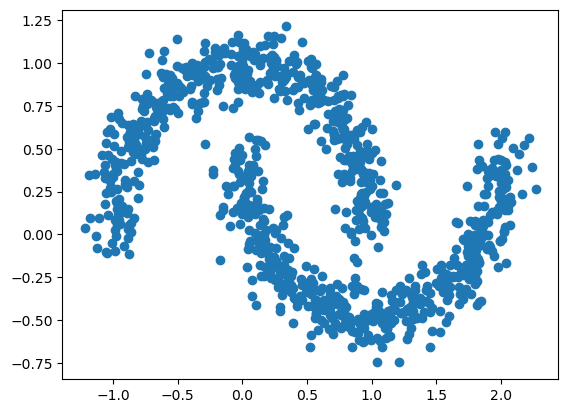

In [3]:
plt.scatter(
    x=data['X1'],
    y=data['X2'],
)

HMMMMMMM! very nice!

But what are the categories here.

We can just colormap the points based on the `y` values to see the pattern.

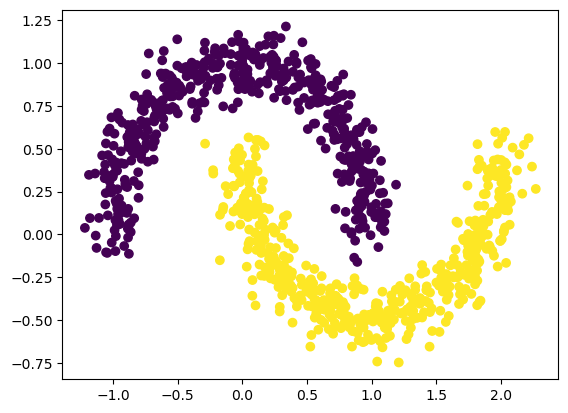

In [4]:
plt.scatter(
    x=data['X1'],
    y=data['X2'],
    c=data['y'],
    cmap='viridis'
)

And we have two nice little half circles with a bit of noise. And the pattern looks nice. Now, What I want you to do is make a dataset with the `make_circles` function and plot it so that you can do your own experiments.

And before going deeper, I want you to go to [this](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.51124&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) website and play around a bit.

Now, Let's see the shapes of our data.

In [5]:
X.shape, y.shape

((1000, 2), (1000,))

In the, feature set we have `1000` rows and `2` columns and the target set we have `1000` rows.

This will come in handy when we build the model.

Now, that we have our data, the next step is to split it into train and test sets.

## Splitting the data

We can use the `train_test_split` function from `sklearn` to split the data into train and test sets.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

And done, we have split the data into train and test sets. The test set will be 20% of the data and the train set will be 80% of the data.

Now, let's make a model.

# Building the model

We can just make a normal neural network model like a regression model. But the problem will arrive very soon.

First let's check the target column.

In [7]:
import numpy as np

print(f"Minimum target value: {y.min()}")
print(f"Maximum target value: {y.max()}")

print(f"Unique target values: {np.unique(y)}")

Minimum target value: 0
Maximum target value: 1
Unique target values: [0 1]


As you can see, the target column has two unique values `0` and `1`. This is called a `binary classification` problem. 

> If the target feature contains only two unique values then it is called a `binary classification` problem.

So, the question for you is, (I'm assuming you already know how to make a regression model) If we take a single neuron in the last layer will it be able to predict `0` and `1` only?

Theoretically, yes. But practically, no.

Let me explain it with an example.

Imagine we train our model to predict whether an email is spam (1) or not spam (0). A single raw neuron calculates a weighted sum of its inputs plus a bias ($z = w \cdot x + b$).

Because this calculation is purely linear, the output can be any continuous number—like 0.85, -2.3, or 105.6. It does not naturally stop at exactly 0 or 1. If a user gets a prediction of 0.74, the computer cannot definitively say "yes" or "no" without extra instructions.

Now, how do we fix this?

We pass the output neuron through an activation function. More specifically a function that will output a number between 0 and 1. So, we use the `sigmoid` activation function. 

The sigmoid function takes any real-valued number and maps it to a value between 0 and 1. 

So, if the output of the neuron is 0.74, the sigmoid function will convert it to a value between 0 and 1, which can be interpreted as a probability. If the output is greater than 0.5, we can classify it as spam (1), and if it's less than or equal to 0.5, we classify it as not spam (0).

So, let's build a model.

In [8]:
from keras import activations, layers, models

model = models.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(5, activation=activations.leaky_relu),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

2026-09-08 15:43:28.654571: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788860610.196587  260333 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9510 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

Alright we have a very small model. Only 21 parameters.

And there's something new here too.

The model looks like this:

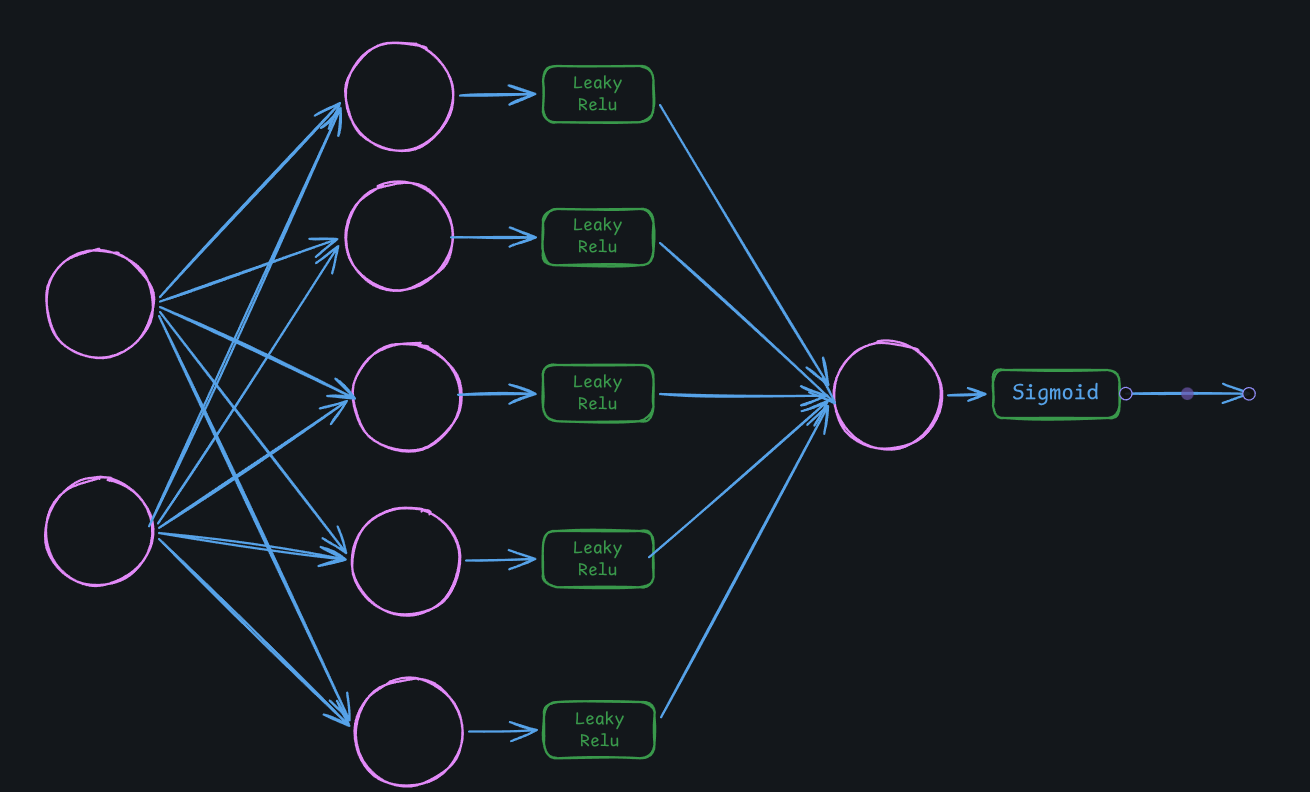

In the hidden layer, I have 5 perceptrons and each have a activation of `leaky_relu`.

**Why I Chose Leaky ReLU Over Standard ReLU?**

To answere this question, first we have to take a look at the range of our feature set.

In [9]:
data[['X1', 'X2']].describe()

,X1,X2
count,1000.000000,1000.000000
mean,0.498507,0.247320
std,0.872305,0.503127
min,-1.219188,-0.745821
25%,-0.052628,-0.210253
50%,0.536469,0.238597
75%,1.064259,0.701185
max,2.270926,1.212253


AS you can see both features have a range from `negetive` to `positive` numbers.

So, What does `ReLu` do?

It takes a number and returns 0 if the number is negetive and the number if it is positive.

So, it literally **removes** the negetive numbers. So, What happends if the activation value from a neuron is negetive? It becomes 0.

When this 0 passes to the next layer, it multiplies by the next layer's weights and stays 0. This means this specific neuron contributes absolutely nothing to the next layer, making its connection completely useless. If too many neurons do this, large parts of your network go dark and stop learning entirely."

> This trap is famously known as the "Dying ReLU" problem.

To prevent our neurons from permanently flatlining, we can swap standard ReLU for `Leaky ReLU`.

Instead of aggressively dropping negative values off a cliff to a hard 0, Leaky ReLU leaves the door slightly ajar. If a value is positive, it leaves it alone. But if a value is negative, it multiplies it by a tiny fraction, usually 0.01. (In tensorflow it is 0.2)

Mathematically, the leaky ReLU activation function is defined as:

$$f(x) = \max(Negetive Slope \times x, x)$$

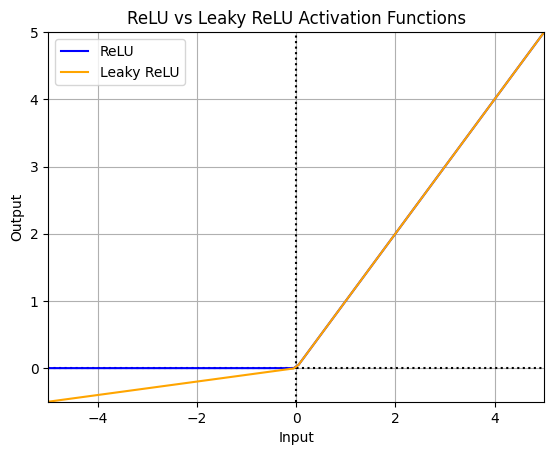

By allowing a tiny "leak" of negative information to flow through, the activation value never becomes a absolute, dead-end zero. When this small value passes to the next layer, its gradient remains alive.

This subtle change ensures that even when our features scale into negative territory like the interlocking coordinates of our make_moons dataset every single neuron retains the ability to adapt, update its weights, and help the model draw a perfectly smooth decision boundary.

I hope you got of that and in the very last layer Im keeping only on one neuron because we are doing a binary classification and it'll have a activation of sigmoid.

Now, Time to Compile.

In [10]:
from keras import losses, metrics, optimizers

model.compile(
    optimizer=optimizers.Adam(),
    loss=losses.BinaryCrossentropy(),
    metrics=[metrics.BinaryAccuracy()]
)

Here, I have used `Adam` optimizer. It's a very powerful optimizer that can handle complex problems. 

But, a little change from before. I have used `BinaryCrossentropy` loss function.

Normally, in regression problems the loos functions will be `mean_squared_error`. But in classification problems we use `BinaryCrossentropy` loss function.

What is `BinaryCrossentropy`?

To understand Binary Cross-Entropy, we have to look at what our model is actually outputting. Because we used a sigmoid activation function in the final layer, our model doesn't just guess a rigid 0 or 1. Instead, it outputs a probability, a decimal number between 0 and 1 (like 0.85, meaning the model is 85% confident the sample belongs to class 1).

A standard regression loss function like mean_squared_error (MSE) only measures the straight-line distance between the prediction and the target. While that works fine for continuous numbers like house prices, it performs terribly for probabilities because it doesn't heavily penalize a model for being confidently wrong. 

**Binary Cross-Entropy fixes this by punishing bad guesses exponentially**.

It calculates a penalty based on how far your predicted probability is from the actual target (0 or 1). It works like a digital referee using a logarithmic scale:

- When the model is right: If the true label is 1 and the model predicts 0.99, the loss is almost `zero`.

- When the model is wrong: If the true label is 1 but the model predicts 0.01 (completely wrong), Binary Cross-Entropy hits the model with a massive, skyrocketing `penalty`.

Mathematically, it forces the model to not just get the answer right, but to become highly confident about its correct answers. By minimizing this loss during training, the Adam optimizer can efficiently steer the weights until the model draws a clean boundary perfectly separating our data.

Mathematically, Binary Cross-Entropy is defined as:

$$BCE = -\frac{1}{n} \sum_{i=1}^n [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]$$

The function look pretty scary but This is a clever math trick! Because the Actual label can only be 1 or 0, one half of that addition always multiplies by zero and completely vanishes, leaving only the part that matters for that specific row."

And One extra thing. I added a extra metrix that is `BinaryAccuracy` which is used to calculate the accuracy of the model.

Binary accuracy function will take the output of the model as probability and convert it to 0 or 1 with the treshold of 0.5.

- If the probability is greater than or equal to 0.5, it will be 1.

- If the probability is less than 0.5, it will be 0.

Well with all that out of the way let's see how my model performs.

In [11]:
import tensorflow as tf

tf.random.set_seed(42)

model.fit(
    x=X_train,
    y=y_train,
    epochs=100
)

Epoch 1/100


2026-09-08 15:43:31.136159: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b40bc005c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-08 15:43:31.136169: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-09-08 15:43:31.147504: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-08 15:43:31.219860: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.5638 - loss: 0.6909   
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.6275 - loss: 0.6746 
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.6988 - loss: 0.6564 
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.7638 - loss: 0.6357 
Epoch 5/100


I0000 00:00:1788860611.584271  260391 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8037 - loss: 0.6132 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8350 - loss: 0.5894 
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8525 - loss: 0.5652 
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8763 - loss: 0.5409 
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8850 - loss: 0.5174 
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8800 - loss: 0.4950 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8788 - loss: 0.4740 
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8775 - loss: 0.4547 
Epoch 13/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8725 - loss: 0.4372 
Epoch 14/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8675 - loss: 0.4213 
Epoch 15/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8625

Well, for only 5 epochs my model is performing pretty bad.

Now you do it. You try to improve it.

Run it for more epochs and see if it gets better.

Now, one cool thing I want to show you is the `decision boundary`. 

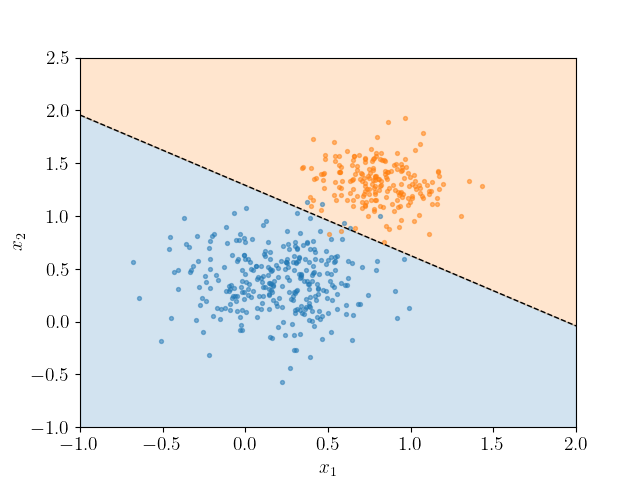

I know you've seen this kind of graphs before and thought how do they make this. This is called a `decision boundary plot`.

For a `regression problem` it's just a line. But for a `classification problem` it cannot be a line.

It's a little hard to understand but here's a algorithm that will help you understand it.

- Define a Mesh Grid containing all possible combinations of two features.
- For each point in the Mesh Grid, predict the class.
- Plot the predicted classes as a color map.
- Overlay the actual classes on top of the color map.

Step are simple. But I want to show you how it works.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_decision_boundary(model, features, target, step_size=0.02, show_probabilities=False):
    """
    Plots the decision boundary (decision regions) for a TensorFlow/Keras model.
    
    Parameters:
    - model: Trained TensorFlow/Keras Sequential model
    - features: Input dataset features (Pandas DataFrame or NumPy array, shape: [n_samples, 2])
    - target: True target labels/classes (Pandas Series or NumPy array, shape: [n_samples])
    - step_size: Resolution of the background mesh grid
    - show_probabilities: Toggles continuous confidence gradients vs sharp class boundaries
    """
    # 1. Extract raw values for calculations, preserving column names if using Pandas
    if isinstance(features, pd.DataFrame):
        feature_names = features.columns.tolist()
        features_arr = features.values
    else:
        feature_names = ["Feature 1", "Feature 2"]
        features_arr = features

    # Ensure target is a standard NumPy array format
    target_arr = target.values if isinstance(target, pd.Series) else target

    # 2. Define grid limits based on the feature spaces
    x_min, x_max = features_arr[:, 0].min() - 0.5, features_arr[:, 0].max() + 0.5
    y_min, y_max = features_arr[:, 1].min() - 0.5, features_arr[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size), 
                         np.arange(y_min, y_max, step_size))

    # print(xx,yy)
    
    # 3. Create the flat grid coordinates for prediction
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Reconstruct a DataFrame if the model expects named inputs
    # if isinstance(features, pd.DataFrame):
    #     grid_points = pd.DataFrame(grid_points, columns=feature_names)

    # 4. Predict over the mesh grid points
    predictions = model.predict(grid_points, verbose=0)
    
    # 5. Reshape predictions back into the 2D grid matrix
    if show_probabilities:
        Z = predictions.reshape(xx.shape)
    else:
        Z = (predictions > 0.5).astype(int).reshape(xx.shape)
        
    # 6. Generate the Plot background
    # plt.figure(figsize=(8, 6))
    
    if show_probabilities:
        contour = plt.contourf(xx, yy, Z, levels=20, cmap=plt.cm.plasma, alpha=0.4)
        plt.colorbar(contour, label="Model Confidence / Probability")
    else:
        plt.pcolormesh(xx, yy, Z, cmap=plt.cm.plasma, alpha=0.3, shading="auto")
    
    # 7. Scatter the true historical data points on top
    plt.scatter(features_arr[:, 0], features_arr[:, 1], c=target_arr, cmap=plt.cm.RdYlBu, edgecolor="k", s=40)
    
    # 8. Apply dynamic styling
    plt.title("Model Decision Boundary")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    # plt.show()
    


The above Function will take the model, the features and the target and plot the decision boundary plot. You can copy it and paste it into your code if you want take a deeper look and understand the algorithm.

> I got the idea and also reference code from [cs231n](https://cs231n.github.io/neural-networks-case-study/). It's a nice resource for unserstanding how Neural Networks works in classification problems and in general.

Now, I'll use this to plot the decision boundary for my model.

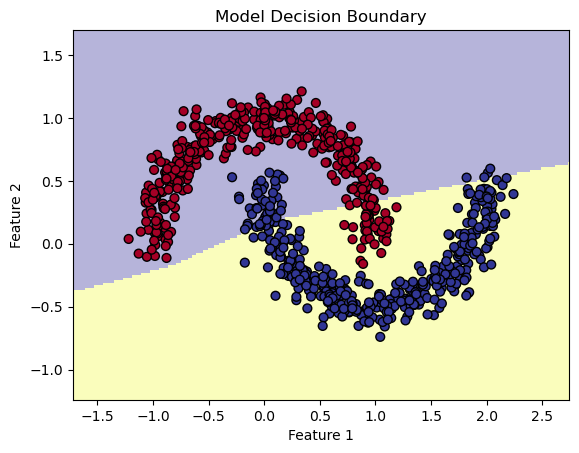

In [13]:
plot_decision_boundary(model, X_train, y_train)

Nice.

Now, you can clearly see the model is trying to learn the pattern of the data and the boundary where the two classes are separated. And it really looks great.

And just for flecing reasons, I also implemented the probability plot as well. Inside that function.

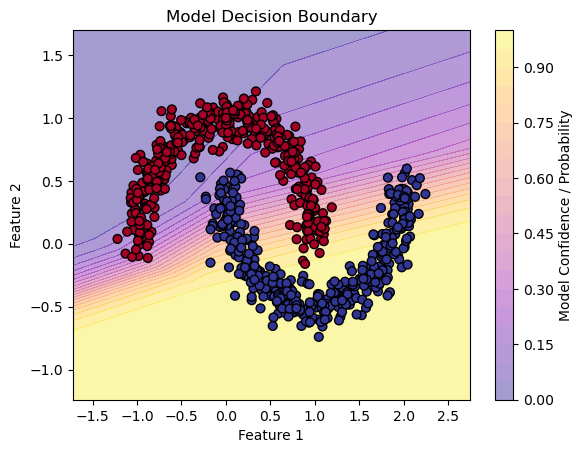

In [14]:
plot_decision_boundary(model, X_train, y_train, show_probabilities=True)

> Decision boundary is just predicting the class of every point in a 2D grid then coloring it.

And this is a really nice way to visualize the model's performance.

But here's a question for we Is this the final verdict. This is the training set performance, right?

We should see the performance on the test set as well.

Let's see the training and test set perfomrnace side by side.

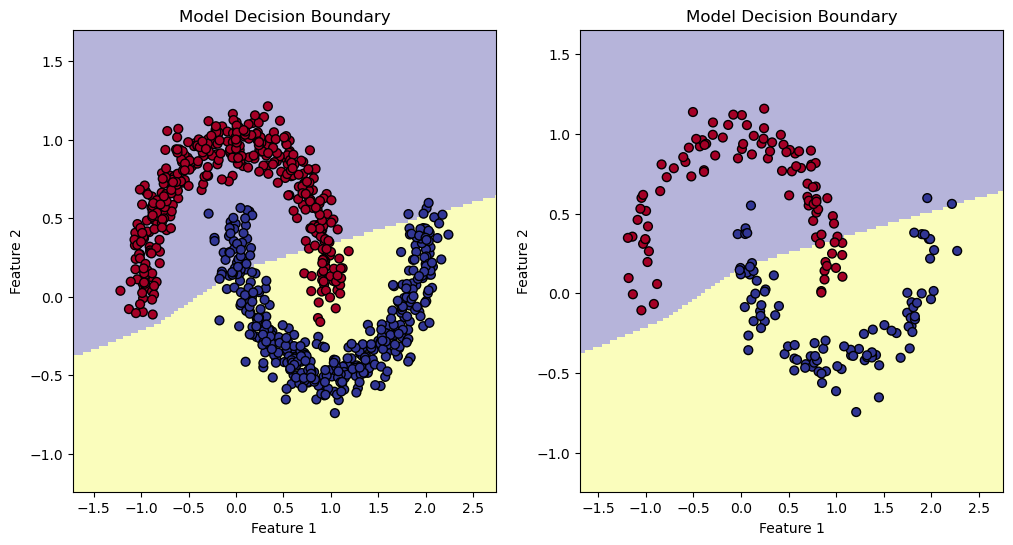

In [15]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model, X_test, y_test)

plt.show()

Both seem very similler.

And now clealy see the model is trying to learn the pattern of the data but it's slow right??

The model learned in 100+ steps and it's still a little behind.

Now we can do a lot of thing to make the model learn.

- More epochs.
- More hidden layers.
- More neurons.
- Different activation functions.
- Different optimizers.
- Different loss functions.

Except for the first option almost everything else means we are making a new model. We dont want to do that.

So, is there a way to make the model learn faster?

Yes, there is.

## Learning Rate

The learning rate is a hyperparameter that controls how fast the model learns. It's connected to the optimizer you use for a model.

We can tune the learning rate to make the model learn faster.

I'll make a new model that will be the exact copy of the previous one but with a different learning rate.

In [16]:
model_2 = models.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(5, activation=activations.leaky_relu),
    layers.Dense(1, activation='sigmoid')
])

model_2.compile(
    # >>>>>>>>>>>>>>>>>>>>>>>>>>
    # Learning Rate Changed to 0.01
    # <<<<<<<<<<<<<<<<<<<
    optimizer=optimizers.Adam(learning_rate=0.01),
    loss=losses.BinaryCrossentropy(),
    metrics=[metrics.BinaryAccuracy()],
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

By default the learning rate is 0.001. Now, I changed it to 0.01.

A learning rate of 0.001 means that during training, the model calculates the gradient (the direction and steepness of the error) and adjusts its weights by multiplying that gradient by 0.001.

Mathematically, the formula for updating a weight looks like this:

$$(\text{New\ Weight}=\text{Old\ Weight}-(\text{Learning\ Rate}\times \text{Gradient}))$$

When the learning rate is 0.001, the step size is highly restricted. Even if the gradient is large, multiplying it by 0.001 shrinks the actual change to a tiny fraction.

By changing the learning rate to 0.01, we are multiplying the gradient by a factor 10 times larger than before. Now, every time the model learns a lesson from a batch of data, it applies that adjustment with 10 times more force. This allows the weights to shift rapidly toward their optimal values, significantly speeding up the training process for our interlocking moons.

Let's train the model again and see this time if the process speeds up.

In [17]:
model_2.fit(X_train, y_train, epochs=100)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.6413 - loss: 0.7308   
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.7962 - loss: 0.5135 
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8250 - loss: 0.3904 
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8375 - loss: 0.3307 
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8475 - loss: 0.3003 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8575 - loss: 0.2805 
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8700 - loss: 0.2669 
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8850 - loss: 0.2569 
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8950 - loss: 0.2487 
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8950 - loss: 0.2415 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accura

WOOOOOOOOO! Would you look at that???!!!

Almost 100% accuracy on the training set. OMA!!!!

Even though the loss is still not zero but it's very close to zero.

Now, let's see how the model performs on the test set.

In [18]:
model_2.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 1.0000 - loss: 0.0133


[0.013257155194878578, 1.0]

And 100% accuracy on the test set as well.

Let's see the decision boundary.

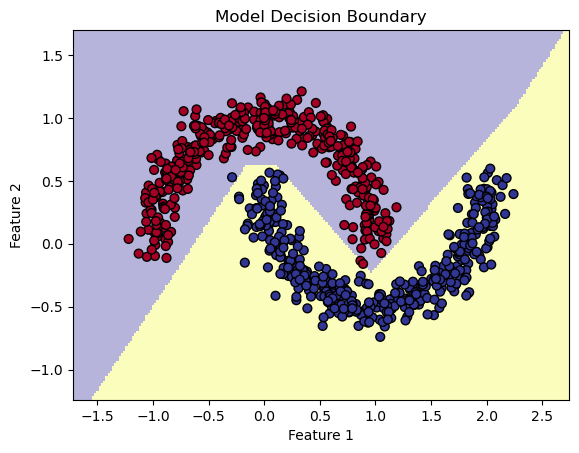

In [19]:
plot_decision_boundary(model_2, X_train, y_train)

Would you look at that?? It's like the model learned the whole pattern of the data.

And it did it in just 100 steps.

I want to see the loss decrease over time.

<Axes: >

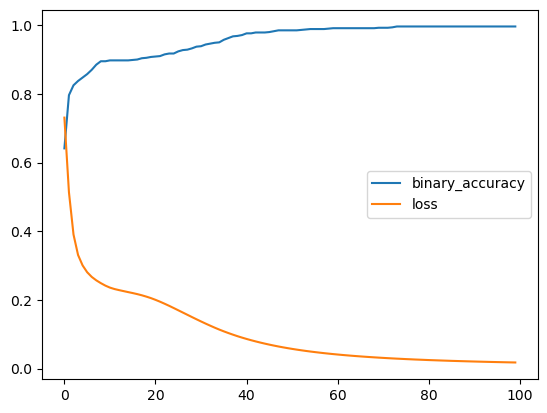

In [20]:
pd.DataFrame(model_2.history.history).plot()

Just wow!

So, as you can see the model is learning waaay faster than before and the model as perfect accuracy on test and training sets. I wont train it for any longer because From the decision coundary graph I see that if I train the model has the risk of over fitting the data.

But I want to talk about another thing.

How do We know which learning rate is best?

If the learning rate is too high, the model will have a very time finding the right weights(this is called overshooting) and loss will bounce back and forth.

And if the learning rate is too low, the model will take a long time to learn the weights and sometime be very overfitted.

For my case the learning rate was just right.

So, how do we know which learning rate is best?

We can make a graph that can show us the loss over time for different learning rates.

We can make a function that will change the learnign rate from low to high while training model and we can see how the loss changes as the learning rate changes from very low to very high.

In [21]:
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-5 * 10**(epoch / 18)
)

`LearningRateScheduler` is a subclass of `Callback` that allows you to dynamically adjust the learning rate during training.

> This is called a keras callback, you can also refered to as a scheduler.

This class will take a function as an argument that will get the current epoch index and current learning rate and return a new learning rate.

Now, I made a lambda function that will change the learning rate from low to high exponentially while training the model.

Here's how the learning rate will change over time:

In [22]:
epochs = np.arange(100)
lr = 1e-5 * 10**(epochs / 18)
lr

array([1.00000000e-05, 1.13646367e-05, 1.29154967e-05, 1.46779927e-05,
       1.66810054e-05, 1.89573565e-05, 2.15443469e-05, 2.44843675e-05,
       2.78255940e-05, 3.16227766e-05, 3.59381366e-05, 4.08423865e-05,
       4.64158883e-05, 5.27499706e-05, 5.99484250e-05, 6.81292069e-05,
       7.74263683e-05, 8.79922544e-05, 1.00000000e-04, 1.13646367e-04,
       1.29154967e-04, 1.46779927e-04, 1.66810054e-04, 1.89573565e-04,
       2.15443469e-04, 2.44843675e-04, 2.78255940e-04, 3.16227766e-04,
       3.59381366e-04, 4.08423865e-04, 4.64158883e-04, 5.27499706e-04,
       5.99484250e-04, 6.81292069e-04, 7.74263683e-04, 8.79922544e-04,
       1.00000000e-03, 1.13646367e-03, 1.29154967e-03, 1.46779927e-03,
       1.66810054e-03, 1.89573565e-03, 2.15443469e-03, 2.44843675e-03,
       2.78255940e-03, 3.16227766e-03, 3.59381366e-03, 4.08423865e-03,
       4.64158883e-03, 5.27499706e-03, 5.99484250e-03, 6.81292069e-03,
       7.74263683e-03, 8.79922544e-03, 1.00000000e-02, 1.13646367e-02,
      

For 100 epochs the range is 10e-5 to 3.16.

> A learninf rate of 3 is considered very high.

This is `3000` times higher than the default learning rate of 0.001.

So, let's use this `scheduler` to train the model.

In [23]:

tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(5, activation=activations.leaky_relu),
    layers.Dense(1, activation='sigmoid')
])

model_3.compile(
    optimizer=optimizers.Adam(),
    loss=losses.BinaryCrossentropy(),
    metrics=[metrics.BinaryAccuracy()],
)

model_3.summary()

# >>>>>>>>>
# add the scheduler to the model while training it as a callback
# <<<<<<<<
model_3.fit(X_train, y_train, epochs=100, callbacks=[lr_scheduler],)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.3738 - loss: 0.7483 - learning_rate: 1.0000e-05
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.3762 - loss: 0.7480 - learning_rate: 1.1365e-05
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.3762 - loss: 0.7476 - learning_rate: 1.2915e-05
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.3800 - loss: 0.7472 - learning_rate: 1.4678e-05
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.3850 - loss: 0.7468 - learning_rate: 1.6681e-05
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.3862 - loss: 0.7463 - learning_rate: 1.8957e-05
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.3913 - loss: 0.7458 - learning_rate: 2.1544e-05
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.3950 - loss: 0.7451 - learning_rate: 2.4484e-05
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0

And The model is trained.

Let's see how the model loss changes over time.

<Axes: >

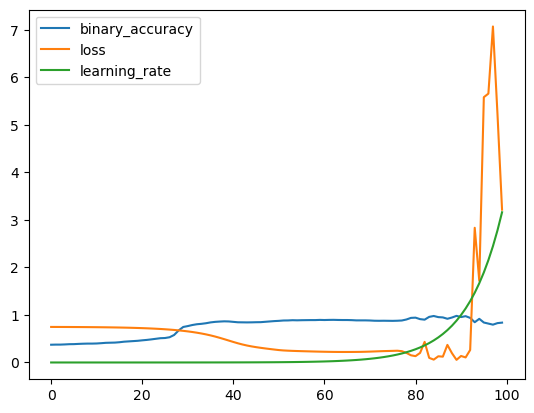

In [24]:
pd.DataFrame(
    model_3.history.history
).plot()

Three line??

Yes, that's right. When you add a scheduler, The learning rate changes over time is also stored in the history.

and you can see as the learning rate increases the loss decreases at first but after the learning increases too much the loss starts to increase again and starts to bounce back and forth.

But it's hard to specify the best learning rate from this we should make a graph that will show us the loss over time for different learning rates.

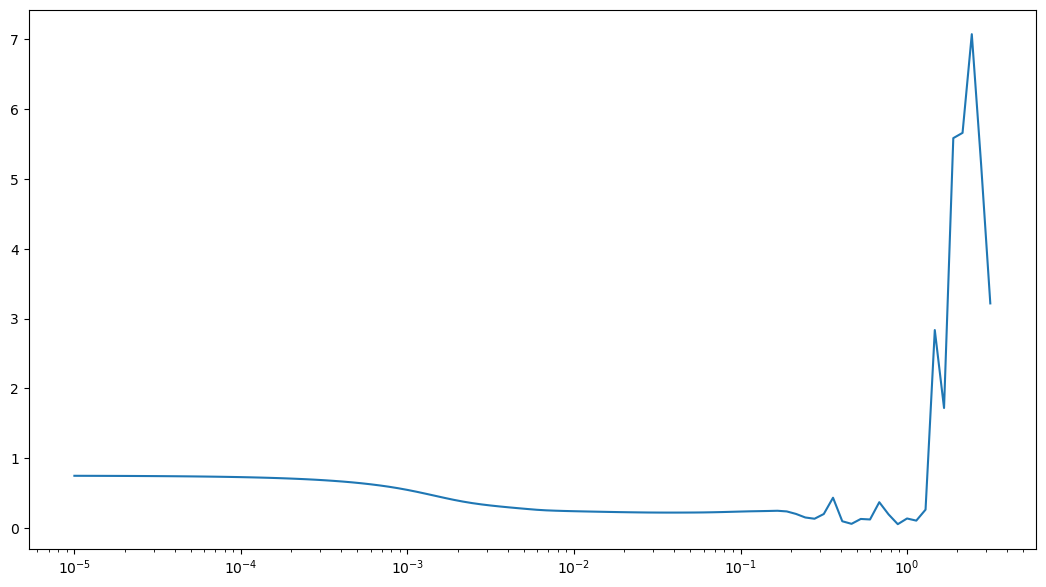

In [25]:

plt.figure(figsize=(13,7))

plt.semilogx(
    model_3.history.history['learning_rate'],
    model_3.history.history['loss']
)

plt.show()

Now, what does this graph tell us?

This graph shows for our model when the learnign rate becomes too high for the loss to decrease.

Now how do We use this graph to find the ideal learning rate?

To find the ideal learning rate the rule of thumb is to find the learning rate where the loss is still decreasing not exactly flat.

In our graph we can see that the loss is still decreasing from 0.001 to just right before 0.1. Then it start the dance.

So, we can chose a learning rate between 0.001 and 0.1. But it is best practice to choose a value 10 time smaller than the maximum learning rate where the loss is still decreasing.

That would be `0.01` in our case.

Guess what? By sheer coincedence I set the learning rate to 0.01 in model_2.

But this time let's set a value closer to `0.1` in model_3. How about `0.05`?

Let's see if our very bad model can learn with this learning rate.


In [26]:

tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(5, activation=activations.leaky_relu),
    layers.Dense(1, activation='sigmoid')
])

model_4.compile(
    optimizer=optimizers.Adam(0.05),
    loss=losses.BinaryCrossentropy(),
    metrics=[metrics.BinaryAccuracy()],
)

model_4.summary()

model_4.fit(X_train, y_train, epochs=100)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8662 - loss: 0.3093   
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8888 - loss: 0.2484 
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8913 - loss: 0.2380 
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8950 - loss: 0.2304 
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8975 - loss: 0.2253 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8963 - loss: 0.2215 
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8975 - loss: 0.2177 
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9050 - loss: 0.2128 
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9100 - loss: 0.2056 
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9175 - loss: 0.1829 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accura

Yes, this is actually faster than model_2.

Let's see the decision boundary.

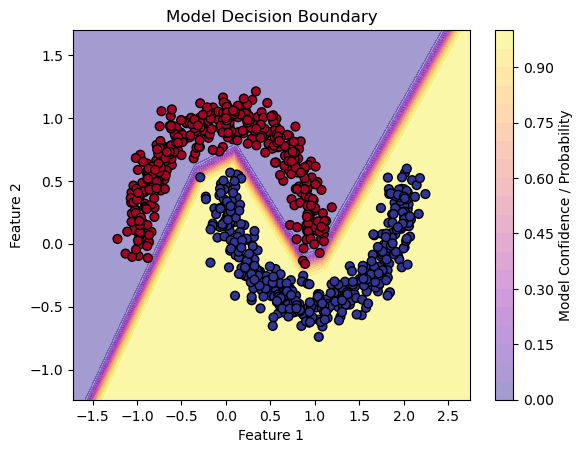

In [27]:
plot_decision_boundary(model_4, X_train, y_train, show_probabilities=True)

Look at that, Nice right... It's fater and more accurate.

I hope You Understood all that... 

# Classification Model Evaluation

Now Before we get started with the multi-class classification let's have a look at how to evaluate a classification model.

There are a lot of metrics that you can use to evaluate a classification model.

- Accuracy
- Precision
- Recall
- F1 Score
- ROC Curve
- AUC
- Confusion Matrix

But in all of that the last one is the most important one.

Although I've talked about it a lot in my prior articles, I'll just give you the basic idea here.

> you can read the whole article [here](https://github.com/RishatTalukder/Machine-Learning-Zero-to-Hero/blob/main/6_Introduction_Machine_learning/14_A_Small_Introduction_to_Machine_Learning.ipynb)

## What is a Confusion Matrix?

A confusion matrix is a table that shows the performance of a classification model.

It shows the number of true positives, true negatives, false positives and false negatives.

It's a very useful tool for evaluating the performance of a classification model.

Let's say we have something like this:

| Target | Predicted |
|--------|-----------|
| 0      | 0         |
| 0      | 1         |
| 1      | 0         |
| 1      | 1         |
| 1      | 1         |
| 1      | 1         |
| 1      | 0         |
| 1      | 1         |

Now, If I ask you to evaluate a model according to this table, what would you say?

You'll just count the number time the model predicted correctly right? And then just give me the ratio of that number to the total number of samples. That's accuracy. 

Confusion matrix makes it easy to not just find the accuracy but a lot more.

|        | Predicted 0 | Predicted 1 |
|--------|-------------|-------------|
| Actual 0 | True Negatives | False Positives |
| Actual 1 | False Negatives | True Positives |

This is what a confusion matrix looks like.

- **True Negatives**: The number of samples that were actually 0 and the model predicted 0.
- **False Positives**: The number of samples that were actually 1 but the model predicted 0.
- **False Negatives**: The number of samples that were actually 0 but the model predicted 1.
- **True Positives**: The number of samples that were actually 1 and the model predicted 1.

Now we count:

|        | Predicted 0 | Predicted 1 | Total |
|--------|-------------|-------------|------|
| Actual 0 | TN - 1 | FP - 1 | 2 |
| Actual 1 | FN - 2 | TP - 4 | 6 |
| Total | 3 | 5 | 8 |

Now, we can find:

Accuracy: Accuracy quantifies the ratio of correct predictions (TP and TN) to the total number of predictions. While informative, this metric can be misleading when classes are imbalanced.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

Precision: recision evaluates the proportion of true positive predictions among all positive predictions (TP / (TP + FP)). This metric is crucial when the cost of false positives is high. 


$$Precision = \frac{TP}{TP + FP}$$

Recall: Recall measures the ratio of true positive predictions to the actual number of positive instances (TP / (TP + FN)). This metric is significant when missing positive instances is costly.

$$Recall = \frac{TP}{TP + FN}$$

F1 Score: The F1-Score strikes a balance between precision and recall, making it useful when both false positives and false negatives carry similar importance

$F1 = \frac{2 * Precision * Recall}{Precision + Recall}$

These are all the matrix we can use to evaluate a classification model and all of these can be calculated from the confusion matrix.

I'll use these to evaluate the next multi-class classification model.

# Multi-class Classification
